In [2]:
library(Seurat)
library(ggplot2)
library(dplyr)
library(scales)
library(NICHES)
library(stringr)
library(reshape2)
library(cowplot)

In [3]:
options(warn=-1)

In [4]:
female_8weeks_rds <- readRDS('../combined_female_8weeks.rds')

In [5]:
data.list <- SplitObject(female_8weeks_rds, split.by="sample_type")

In [6]:
data.list[1]
data.list[2]

$taPVAT_Control_8W_F
An object of class Seurat 
20743 features across 6314 samples within 1 assay 
Active assay: RNA (20743 features, 2000 variable features)
 3 layers present: counts, data, scale.data
 2 dimensional reductions calculated: pca, umap


$taPVAT_HF_8W_F
An object of class Seurat 
20743 features across 9151 samples within 1 assay 
Active assay: RNA (20743 features, 2000 variable features)
 3 layers present: counts, data, scale.data
 2 dimensional reductions calculated: pca, umap


In [7]:
table(data.list[[1]]@meta.data['celltype_broad'])
table(data.list[[2]]@meta.data['celltype_broad'])

celltype_broad
       Adipocytes Endothelial_Cells       Fibroblasts      Immune_Cells 
             3789               710               798               491 
Mesothelial_Cells    Neuronal_Cells         Pericytes              SMCs 
              321                14               180                11 

celltype_broad
       Adipocytes Endothelial_Cells       Fibroblasts      Immune_Cells 
             6075               967               976               529 
Mesothelial_Cells    Neuronal_Cells         Pericytes              SMCs 
              375                 7               211                11 

In [8]:
max.cells <- min(ncol(data.list[[1]]),ncol(data.list[[2]])) 

for (i in 1:length(data.list)){
  Idents(data.list[[i]]) <- data.list[[i]]$sample_type
  data.list[[i]] <- subset(data.list[[i]],cells = WhichCells(data.list[[i]],downsample = max.cells))
  Idents(data.list[[i]]) <- data.list[[i]]$celltype_broad
}


In [9]:
max.cells

[1] 6314

In [10]:
distribution <- data.frame(CTRL = table(Idents(data.list[[1]])),
                            HF = table(Idents(data.list[[2]])))
distribution <- reshape2::melt(distribution)

Using CTRL.Var1, HF.Var1 as id variables



In [11]:
distribution

CTRL.Var1,HF.Var1,variable,value
<fct>,<fct>,<fct>,<int>
Adipocytes,Adipocytes,CTRL.Freq,3789
Fibroblasts,Endothelial_Cells,CTRL.Freq,798
Endothelial_Cells,Fibroblasts,CTRL.Freq,710
Immune_Cells,Immune_Cells,CTRL.Freq,491
Pericytes,Pericytes,CTRL.Freq,180
Mesothelial_Cells,Mesothelial_Cells,CTRL.Freq,321
SMCs,Neuronal_Cells,CTRL.Freq,11
Neuronal_Cells,SMCs,CTRL.Freq,14
Adipocytes,Adipocytes,HF.Freq,4188


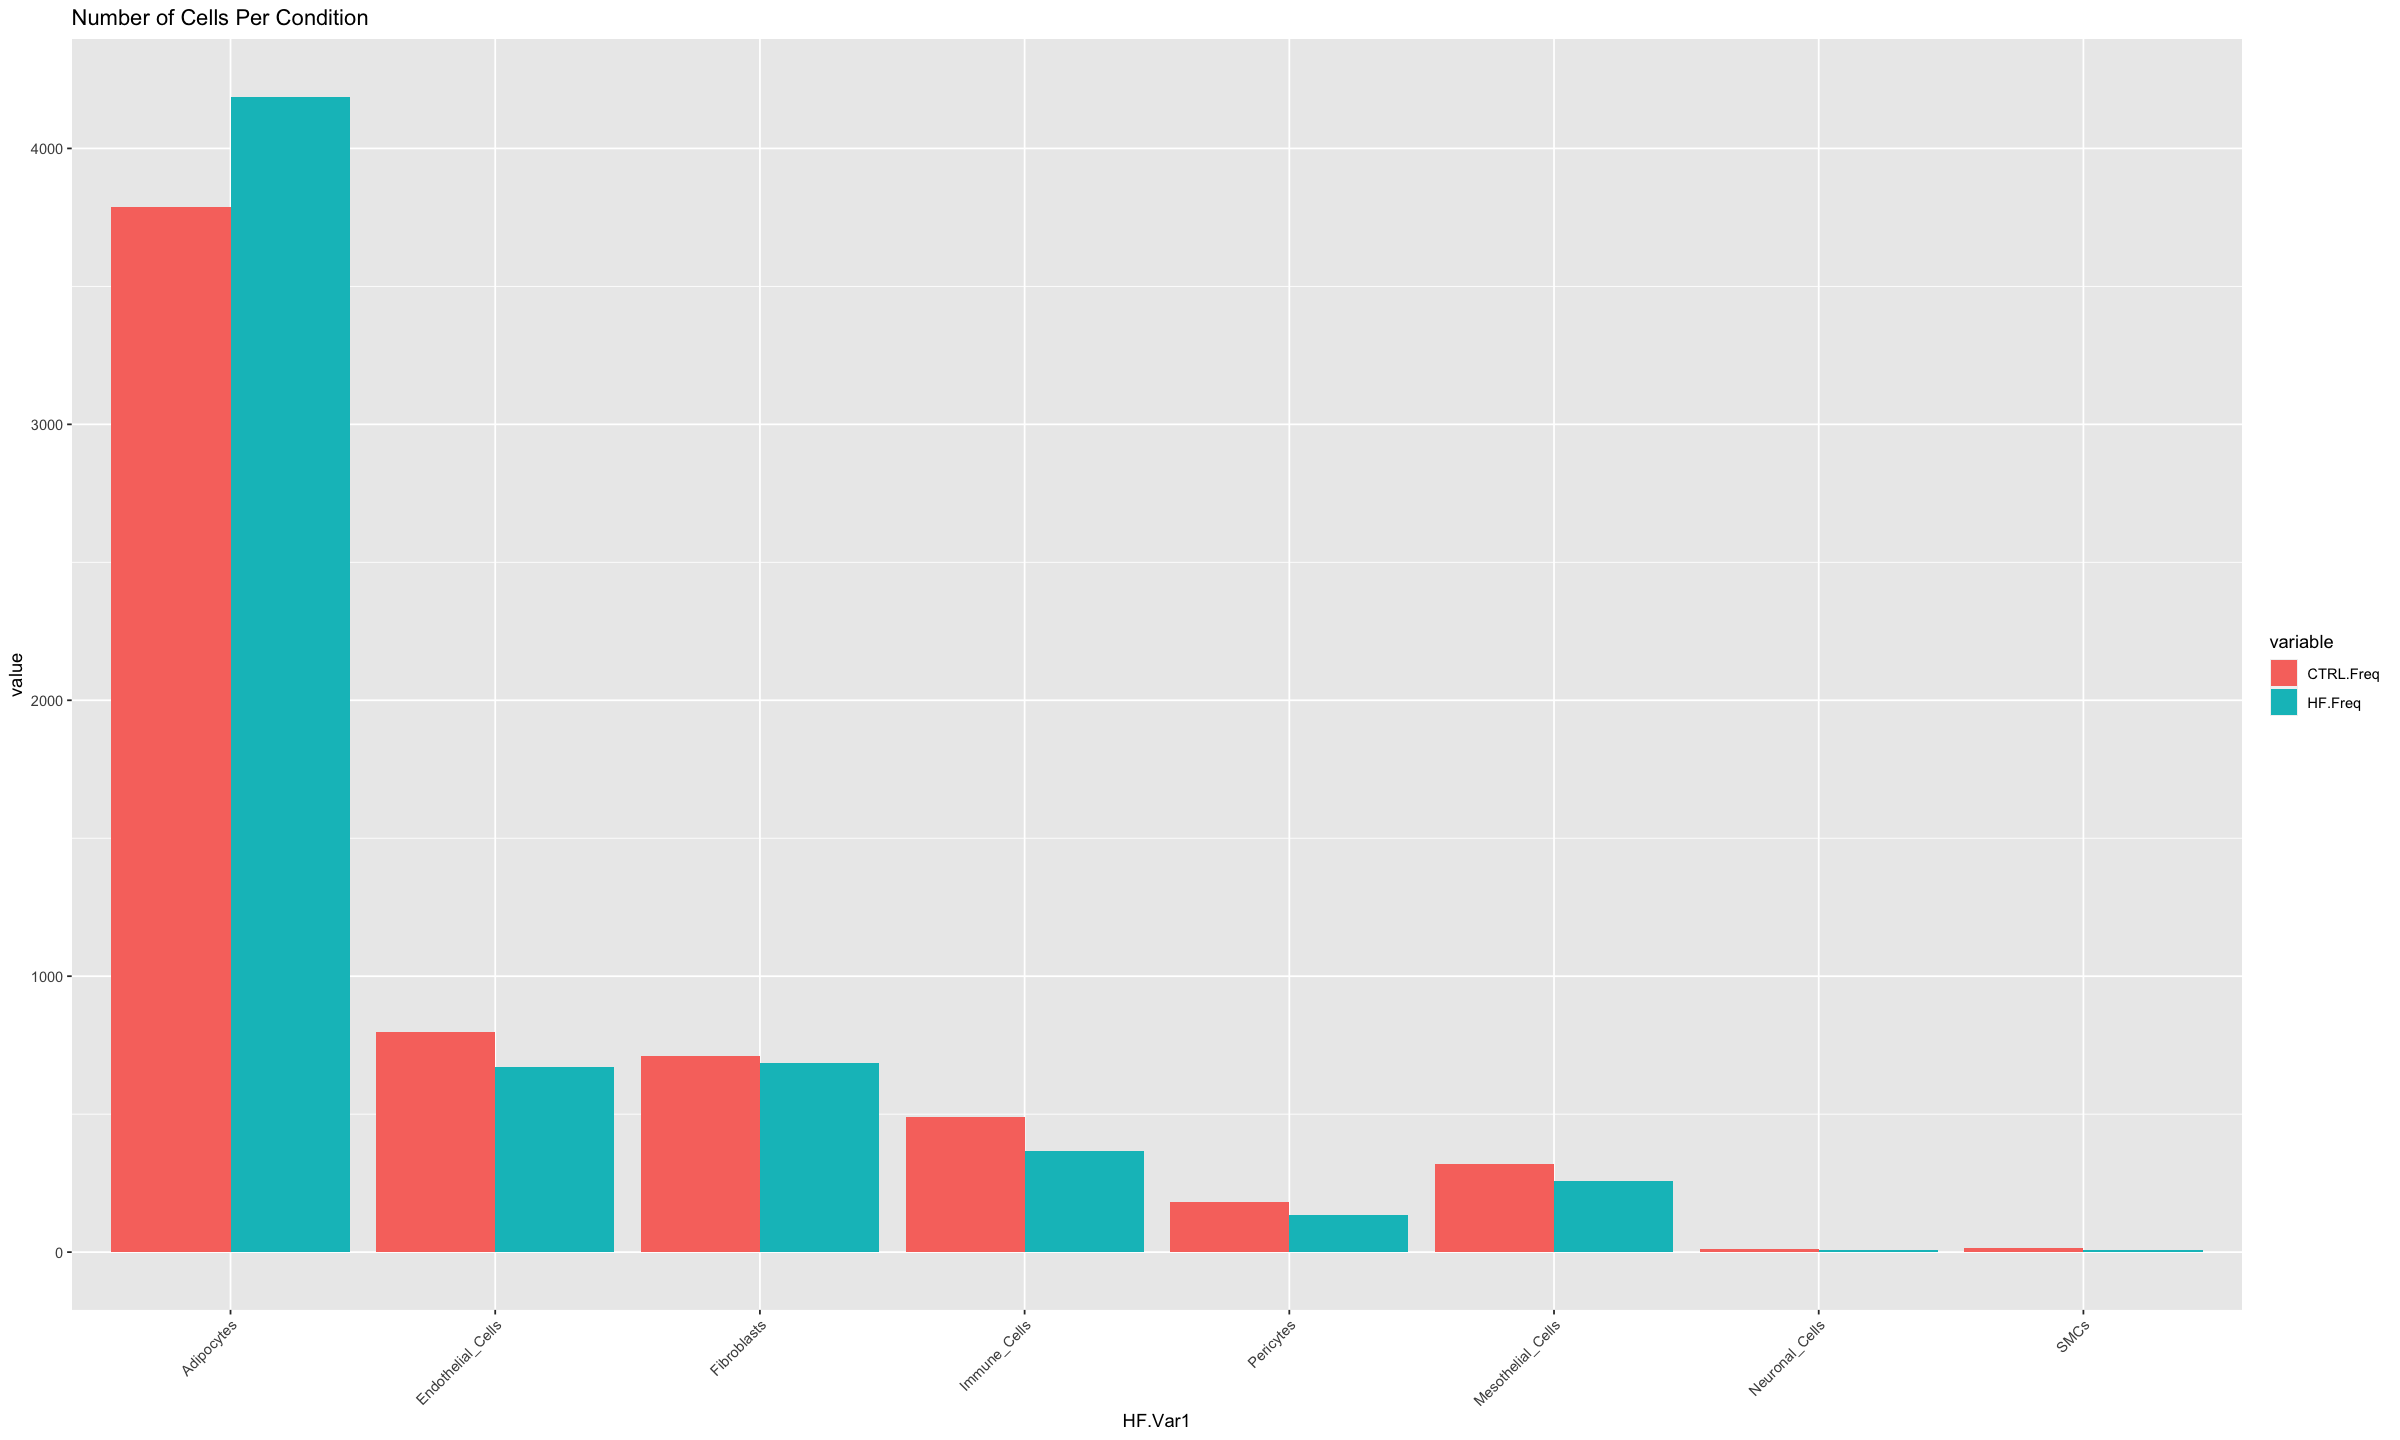

In [12]:
options(repr.plot.width=20, repr.plot.height=12)

ggplot(data = distribution,aes(x = HF.Var1,y=value,fill = variable))+geom_bar(stat='identity',position='dodge')+
  theme(axis.text.x = element_text(angle = 45, vjust = 1, hjust=1))+
  ggtitle('Number of Cells Per Condition')

In [13]:
ncol(data.list[[1]])==ncol(data.list[[2]])

[1] TRUE

In [14]:
table(data.list[[1]]@meta.data['celltype_broad'])
table(data.list[[2]]@meta.data['celltype_broad'])

celltype_broad
       Adipocytes Endothelial_Cells       Fibroblasts      Immune_Cells 
             3789               710               798               491 
Mesothelial_Cells    Neuronal_Cells         Pericytes              SMCs 
              321                14               180                11 

celltype_broad
       Adipocytes Endothelial_Cells       Fibroblasts      Immune_Cells 
             4188               670               684               365 
Mesothelial_Cells    Neuronal_Cells         Pericytes              SMCs 
              259                 6               136                 6 

In [15]:
# Run NICHES on each system and store/name the outputs
scc.list <- list()
for(i in 1:length(data.list)){
  print(i)
  scc.list[[i]] <- RunNICHES(data.list[[i]],
                             LR.database="fantom5",
                             species="mouse",
                             assay="RNA",
                             cell_types = 'celltype_broad',
                             min.cells.per.ident=1,
                             min.cells.per.gene = 50,
                             meta.data.to.map = c('orig.ident','celltype_broad','sample_type'),
                             SystemToCell = T,
                             CellToCell = T,
                             blend = 'mean')
}
names(scc.list) <- names(data.list)

[1] 1


Set cell types as Identity of object internally


 Subsetting to populations with greater than 1 cells


 Subsetting to genes expressed in greater than 50 cells


 6314 distinct cells from 8 celltypes to be analyzed


 Limiting ground truth to genes within dataset


 Mapping against 721 ground truth signaling mechanisms


 For sampling purposes, please make sure that the active Identity of the input seurat object corresponds to cell types

Normalizing layer: counts


 18386 Cell-To-Cell edges computed, sampling 64 distinct VectorTypes, out of 64 total possible

Normalizing layer: counts


 6314 System-To-Cell edges were computed, across 8 cell types



[1] 2


Set cell types as Identity of object internally


 Subsetting to populations with greater than 1 cells


 Subsetting to genes expressed in greater than 50 cells


 6314 distinct cells from 8 celltypes to be analyzed


 Limiting ground truth to genes within dataset


 Mapping against 635 ground truth signaling mechanisms


 For sampling purposes, please make sure that the active Identity of the input seurat object corresponds to cell types

Normalizing layer: counts


 16140 Cell-To-Cell edges computed, sampling 64 distinct VectorTypes, out of 64 total possible

Normalizing layer: counts


 6314 System-To-Cell edges were computed, across 8 cell types



In [16]:
scc.list

$taPVAT_Control_8W_F
$taPVAT_Control_8W_F$CellToCell
An object of class Seurat 
721 features across 18386 samples within 1 assay 
Active assay: CellToCell (721 features, 0 variable features)
 2 layers present: counts, data

$taPVAT_Control_8W_F$SystemToCell
An object of class Seurat 
721 features across 6314 samples within 1 assay 
Active assay: SystemToCell (721 features, 0 variable features)
 2 layers present: counts, data


$taPVAT_HF_8W_F
$taPVAT_HF_8W_F$CellToCell
An object of class Seurat 
635 features across 16140 samples within 1 assay 
Active assay: CellToCell (635 features, 0 variable features)
 2 layers present: counts, data

$taPVAT_HF_8W_F$SystemToCell
An object of class Seurat 
635 features across 6314 samples within 1 assay 
Active assay: SystemToCell (635 features, 0 variable features)
 2 layers present: counts, data



In [17]:
temp.list <- list()
for(i in 1:length(scc.list)){
temp.list[[i]] <- scc.list[[i]]$SystemToCell # Isolate SystemToCell Signaling, which is all that will be covered in this vignette
temp.list[[i]]$Condition <- names(scc.list)[i] # Tag with metadata
}

In [18]:
temp.list[[1]]@meta.data

,orig.ident,nCount_SystemToCell,nFeature_SystemToCell,ReceivingCell,ReceivingType,celltype_broad,sample_type,Condition
,<chr>,<dbl>,<int>,<chr>,<fct>,<chr>,<chr>,<chr>
System—AAACGAACATCCGGCA-1-13,SeuratProject,26.59557,47,AAACGAACATCCGGCA-1-13,Adipocytes,Adipocytes,taPVAT_Control_8W_F,taPVAT_Control_8W_F
System—AAAGAACAGGTTAAAC-1-13,SeuratProject,46.60582,61,AAAGAACAGGTTAAAC-1-13,Fibroblasts,Fibroblasts,taPVAT_Control_8W_F,taPVAT_Control_8W_F
System—AAAGGATGTATTAAGG-1-13,SeuratProject,39.80066,51,AAAGGATGTATTAAGG-1-13,Endothelial_Cells,Endothelial_Cells,taPVAT_Control_8W_F,taPVAT_Control_8W_F
System—AAAGGATTCGTCCATC-1-13,SeuratProject,63.09582,150,AAAGGATTCGTCCATC-1-13,Adipocytes,Adipocytes,taPVAT_Control_8W_F,taPVAT_Control_8W_F
System—AAAGGTACACTTGTCC-1-13,SeuratProject,19.72298,25,AAAGGTACACTTGTCC-1-13,Immune_Cells,Immune_Cells,taPVAT_Control_8W_F,taPVAT_Control_8W_F
System—AAAGGTACATCACAGT-1-13,SeuratProject,85.39324,146,AAAGGTACATCACAGT-1-13,Adipocytes,Adipocytes,taPVAT_Control_8W_F,taPVAT_Control_8W_F
System—AAAGGTAGTTCTAAGC-1-13,SeuratProject,64.87975,206,AAAGGTAGTTCTAAGC-1-13,Adipocytes,Adipocytes,taPVAT_Control_8W_F,taPVAT_Control_8W_F
System—AAAGTCCAGAAACTAC-1-13,SeuratProject,14.40045,24,AAAGTCCAGAAACTAC-1-13,Pericytes,Pericytes,taPVAT_Control_8W_F,taPVAT_Control_8W_F
System—AAAGTCCGTGTGAGCA-1-13,SeuratProject,60.08443,150,AAAGTCCGTGTGAGCA-1-13,Adipocytes,Adipocytes,taPVAT_Control_8W_F,taPVAT_Control_8W_F


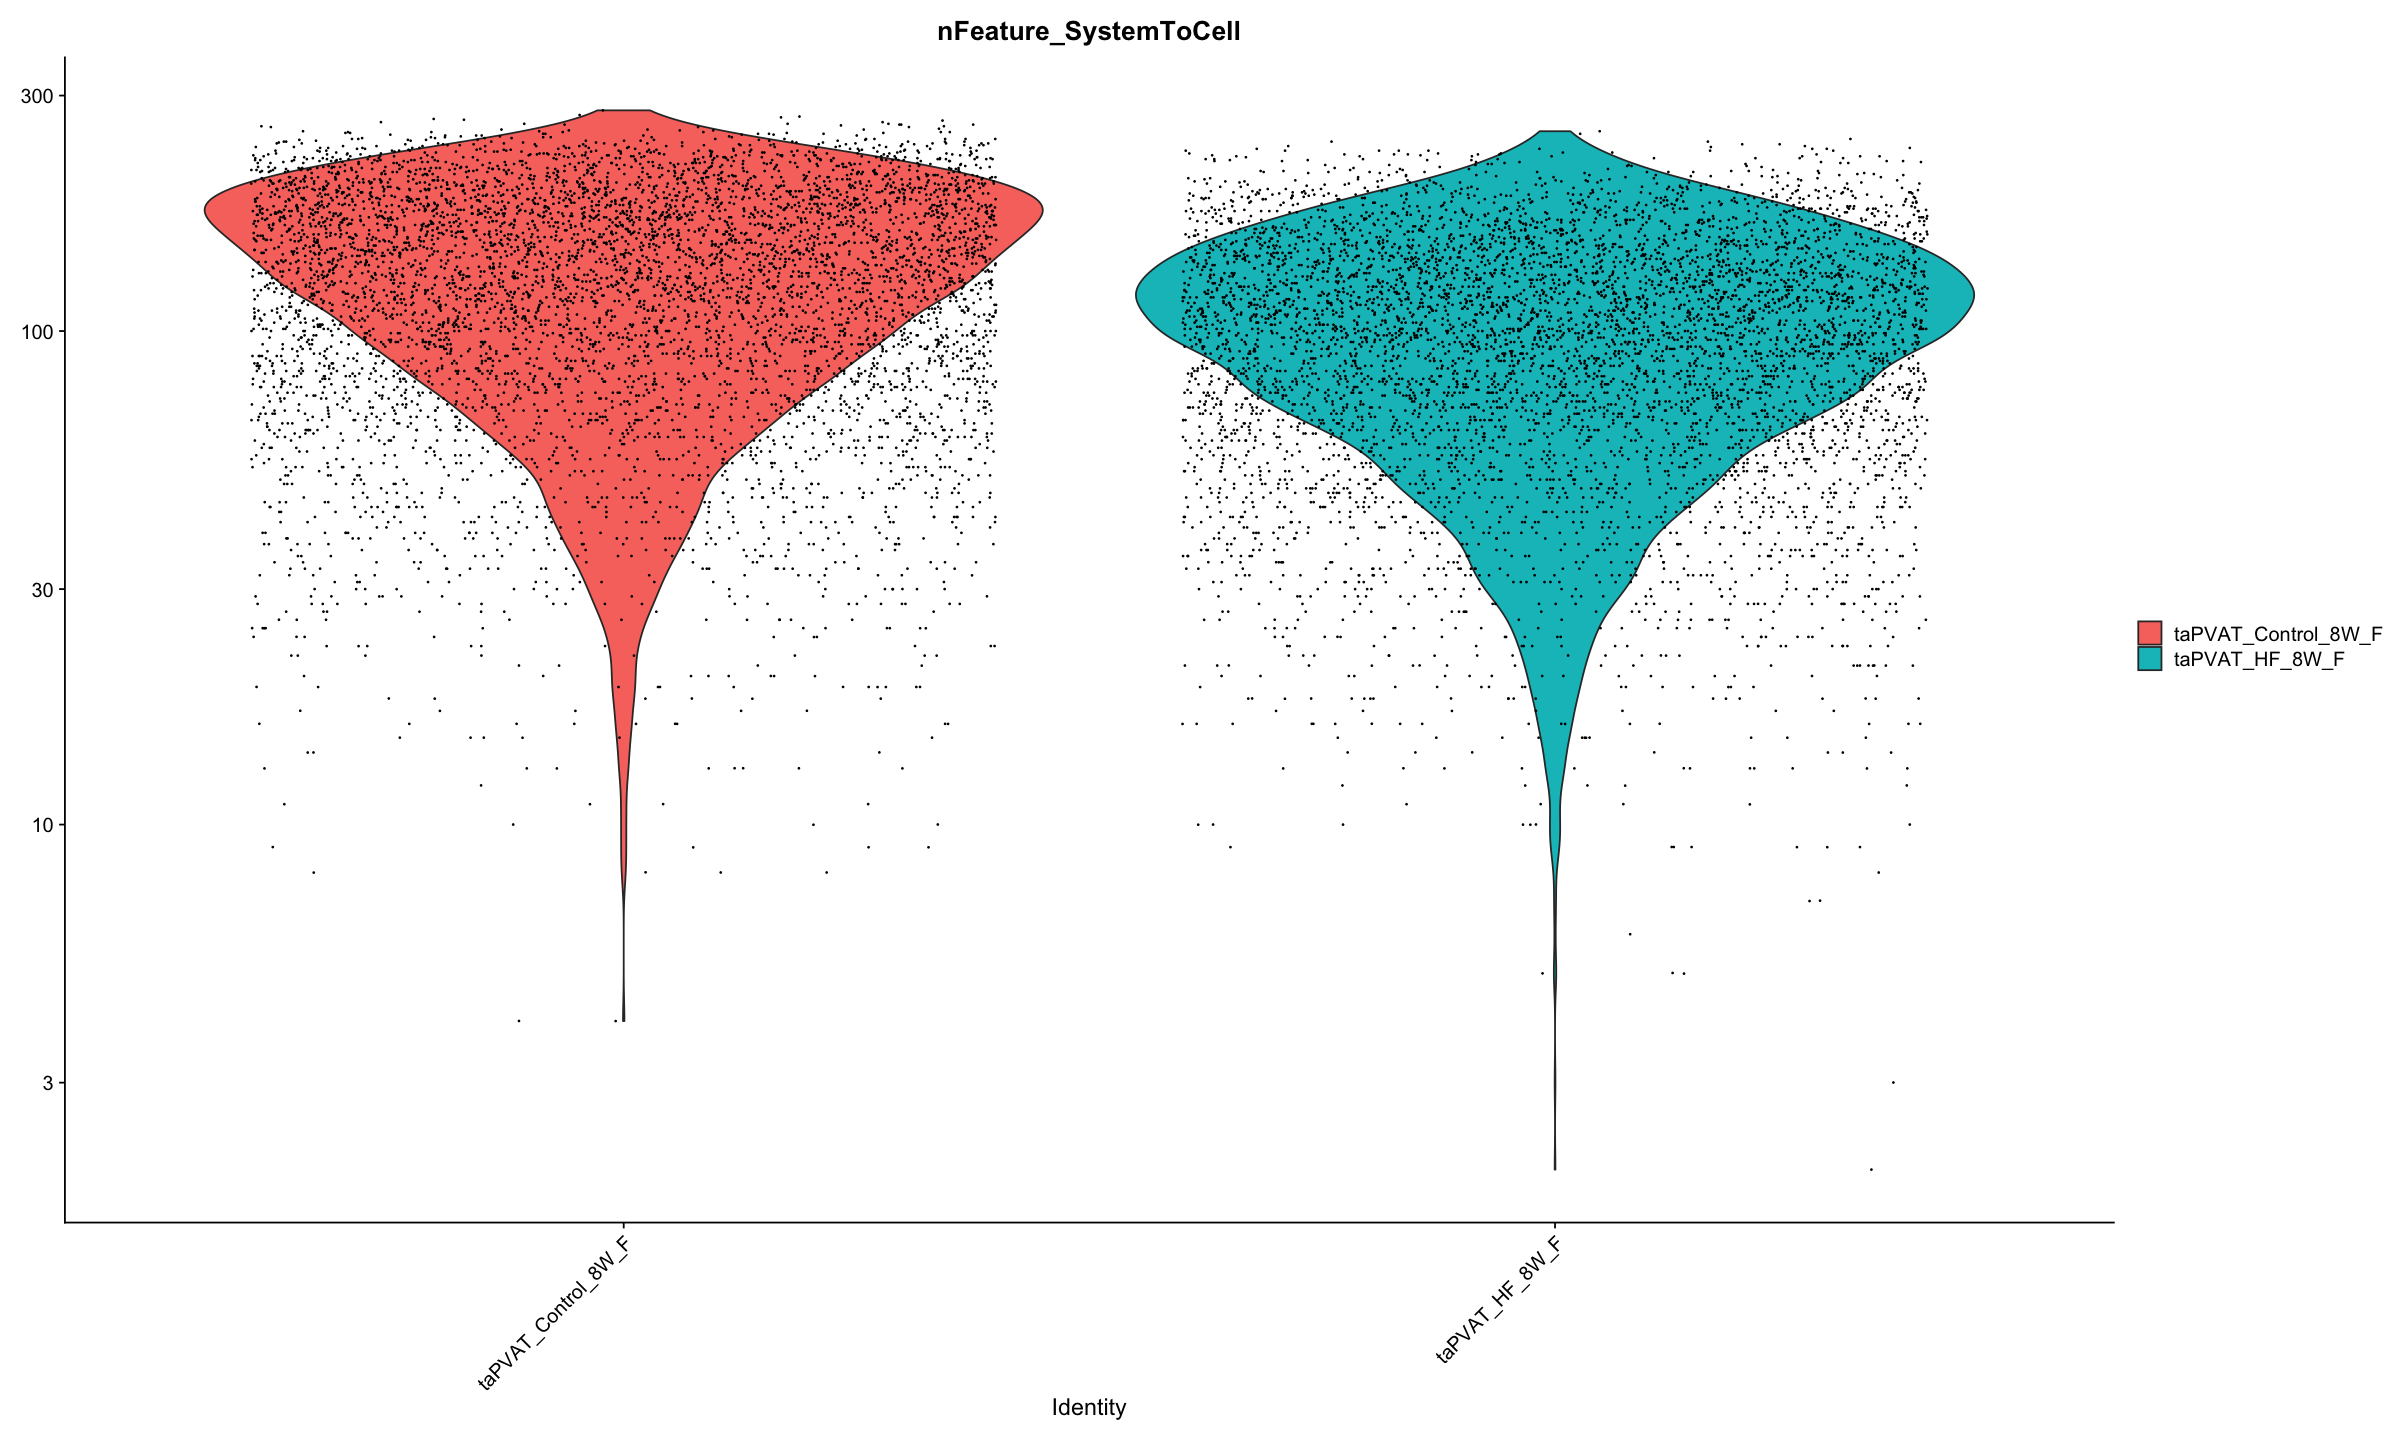

In [19]:
# Merge together
scc.merge <- merge(temp.list[[1]],temp.list[2])

# Clean up low-information crosses (connectivity data can be very sparse)
VlnPlot(scc.merge,features = 'nFeature_SystemToCell',group.by = 'Condition',pt.size=0.1,log = T)

In [20]:
scc.sub <- subset(scc.merge,nFeature_SystemToCell > 5) # Requesting at least 5 distinct ligand-receptor interactions per measurement

Centering and scaling data matrix

Finding variable features for layer data.1

Finding variable features for layer data.2

PC_ 1 
Positive:  Fbn1—Itgb1, Adam12—Itgb1, Col3a1—Itgb1, Lama2—Itgb1, Lamc1—Itgb1, Col1a2—Itgb1, Adam9—Itgb1, Hspg2—Itgb1, Col5a2—Itgb1, Col6a2—Itgb1 
	   Col18a1—Itgb1, Col1a1—Itgb1, Lama5—Itgb1, Tgm2—Itgb1, Adam15—Itgb1, Col4a5—Itgb1, Vcam1—Itgb1, Vcan—Itgb1, Sema7a—Itgb1, Col4a6—Itgb1 
	   Col4a3—Itgb1, Col4a1—Itgb1, Cxcl12—Itgb1, Vegfc—Itgb1, Lamb1—Itgb1, Nid1—Itgb1, Lamb3—Itgb1, Fbln1—Itgb1, Col6a1—Itgb1, F13a1—Itgb1 
Negative:  F8—Lrp1, Lpl—Lrp1, Tfpi—Lrp1, Psap—Lrp1, Serpine1—Lrp1, Hspg2—Ptprs, Apoe—Lrp1, Fgf1—Fgfr1, App—Lrp1, Lrpap1—Lrp1 
	   Plat—Lrp1, Serping1—Lrp1, Nrg2—Erbb4, Egf—Erbb4, Pdgfb—Lrp1, Adam17—Erbb4, Nrg4—Erbb4, Serpine2—Lrp1, Fgf18—Fgfr1, Nrg3—Erbb4 
	   Dcn—Erbb4, Calr—Lrp1, Nrg1—Erbb4, Hsp90b1—Lrp1, Ntf3—Ntrk3, Fgf1—Nrp1, Gnas—Adrb3, Rtn4—Cntnap1, Fgf13—Fgfr1, Ltbp3—Itgb5 
PC_ 2 
Positive:  Igfbp4—Lrp6, Dkk2—Lrp6, Rspo1—Lrp6, Rspo3—Lrp6,

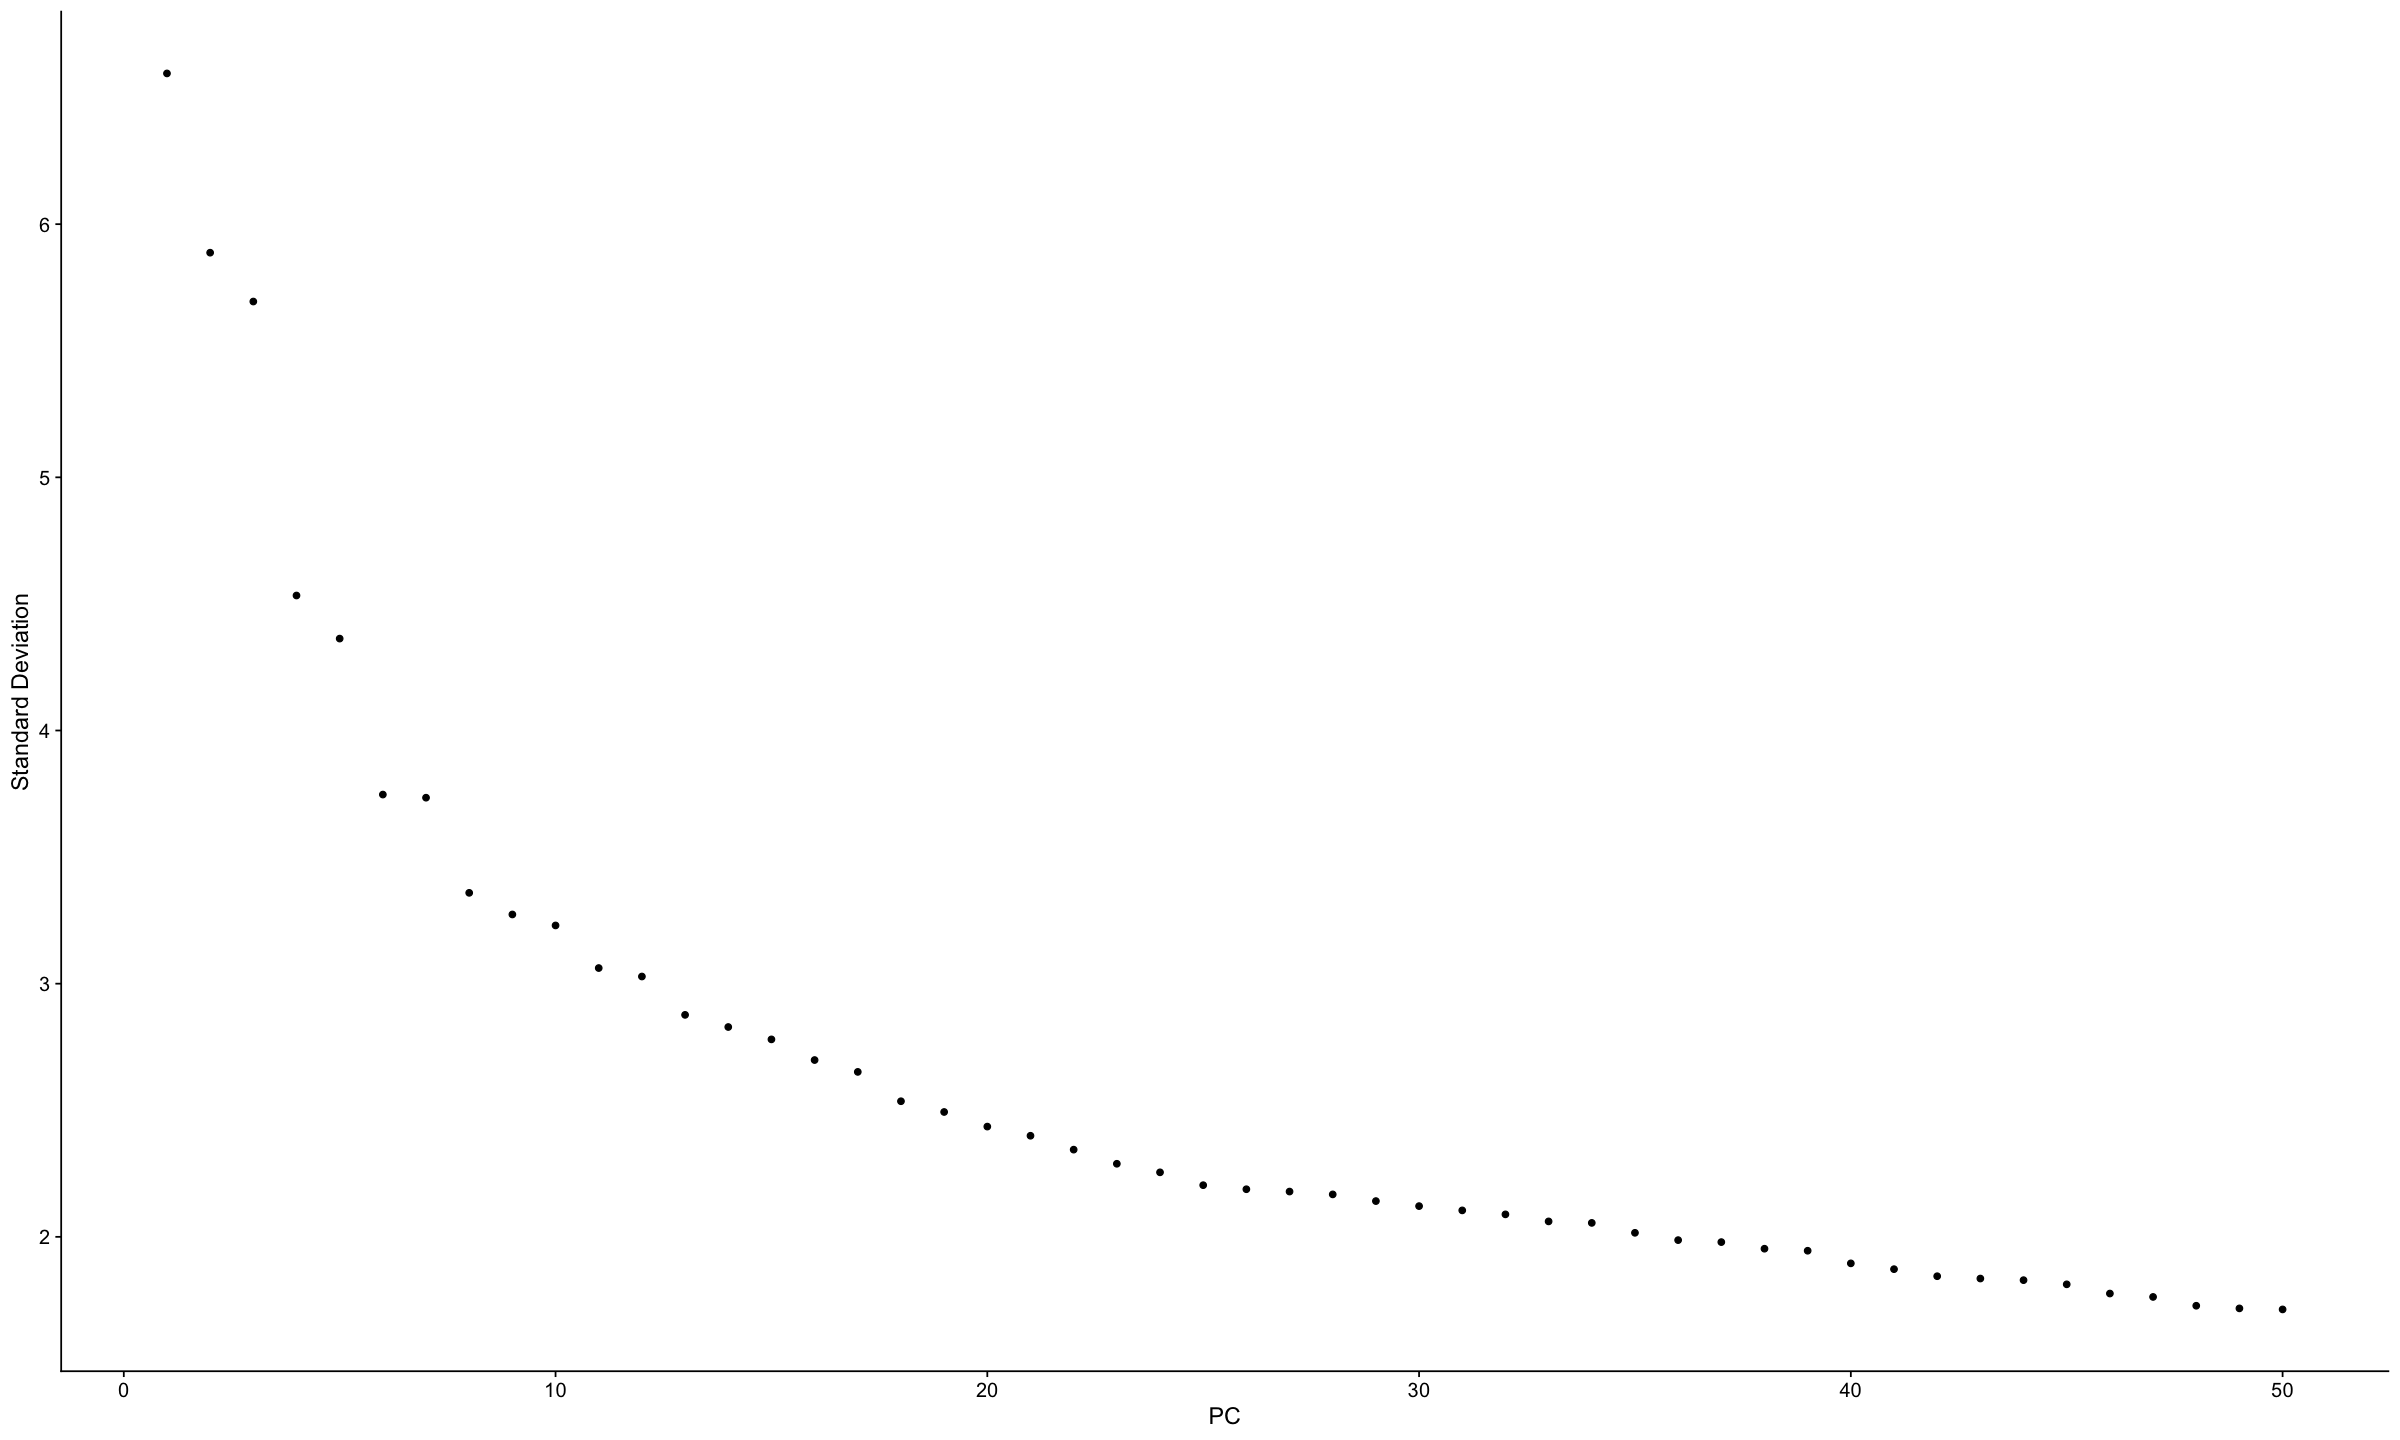

In [21]:
# Perform initial visualization
scc.sub <- ScaleData(scc.sub)
scc.sub <- FindVariableFeatures(scc.sub,selection.method = "disp")
scc.sub <- RunPCA(scc.sub,npcs = 50)
ElbowPlot(scc.sub,ndim=50)

12:44:07 UMAP embedding parameters a = 0.9922 b = 1.112

12:44:07 Read 12620 rows and found 10 numeric columns

12:44:07 Using Annoy for neighbor search, n_neighbors = 30

12:44:07 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

12:44:08 Writing NN index file to temp file /var/folders/kk/5gbzbkc93xb_g56p3bt9t8gh0000gp/T//RtmpoODkoP/file96624e6b16d0

12:44:08 Searching Annoy index using 1 thread, search_k = 3000

12:44:11 Annoy recall = 100%

12:44:12 Commencing smooth kNN distance calibration using 1 thread
 with target n_neighbors = 30

12:44:12 Initializing from normalized Laplacian + noise (using RSpectra)

12:44:13 Commencing optimization for 200 epochs, with 486568 positive edges

12:44:24 Optimization finished



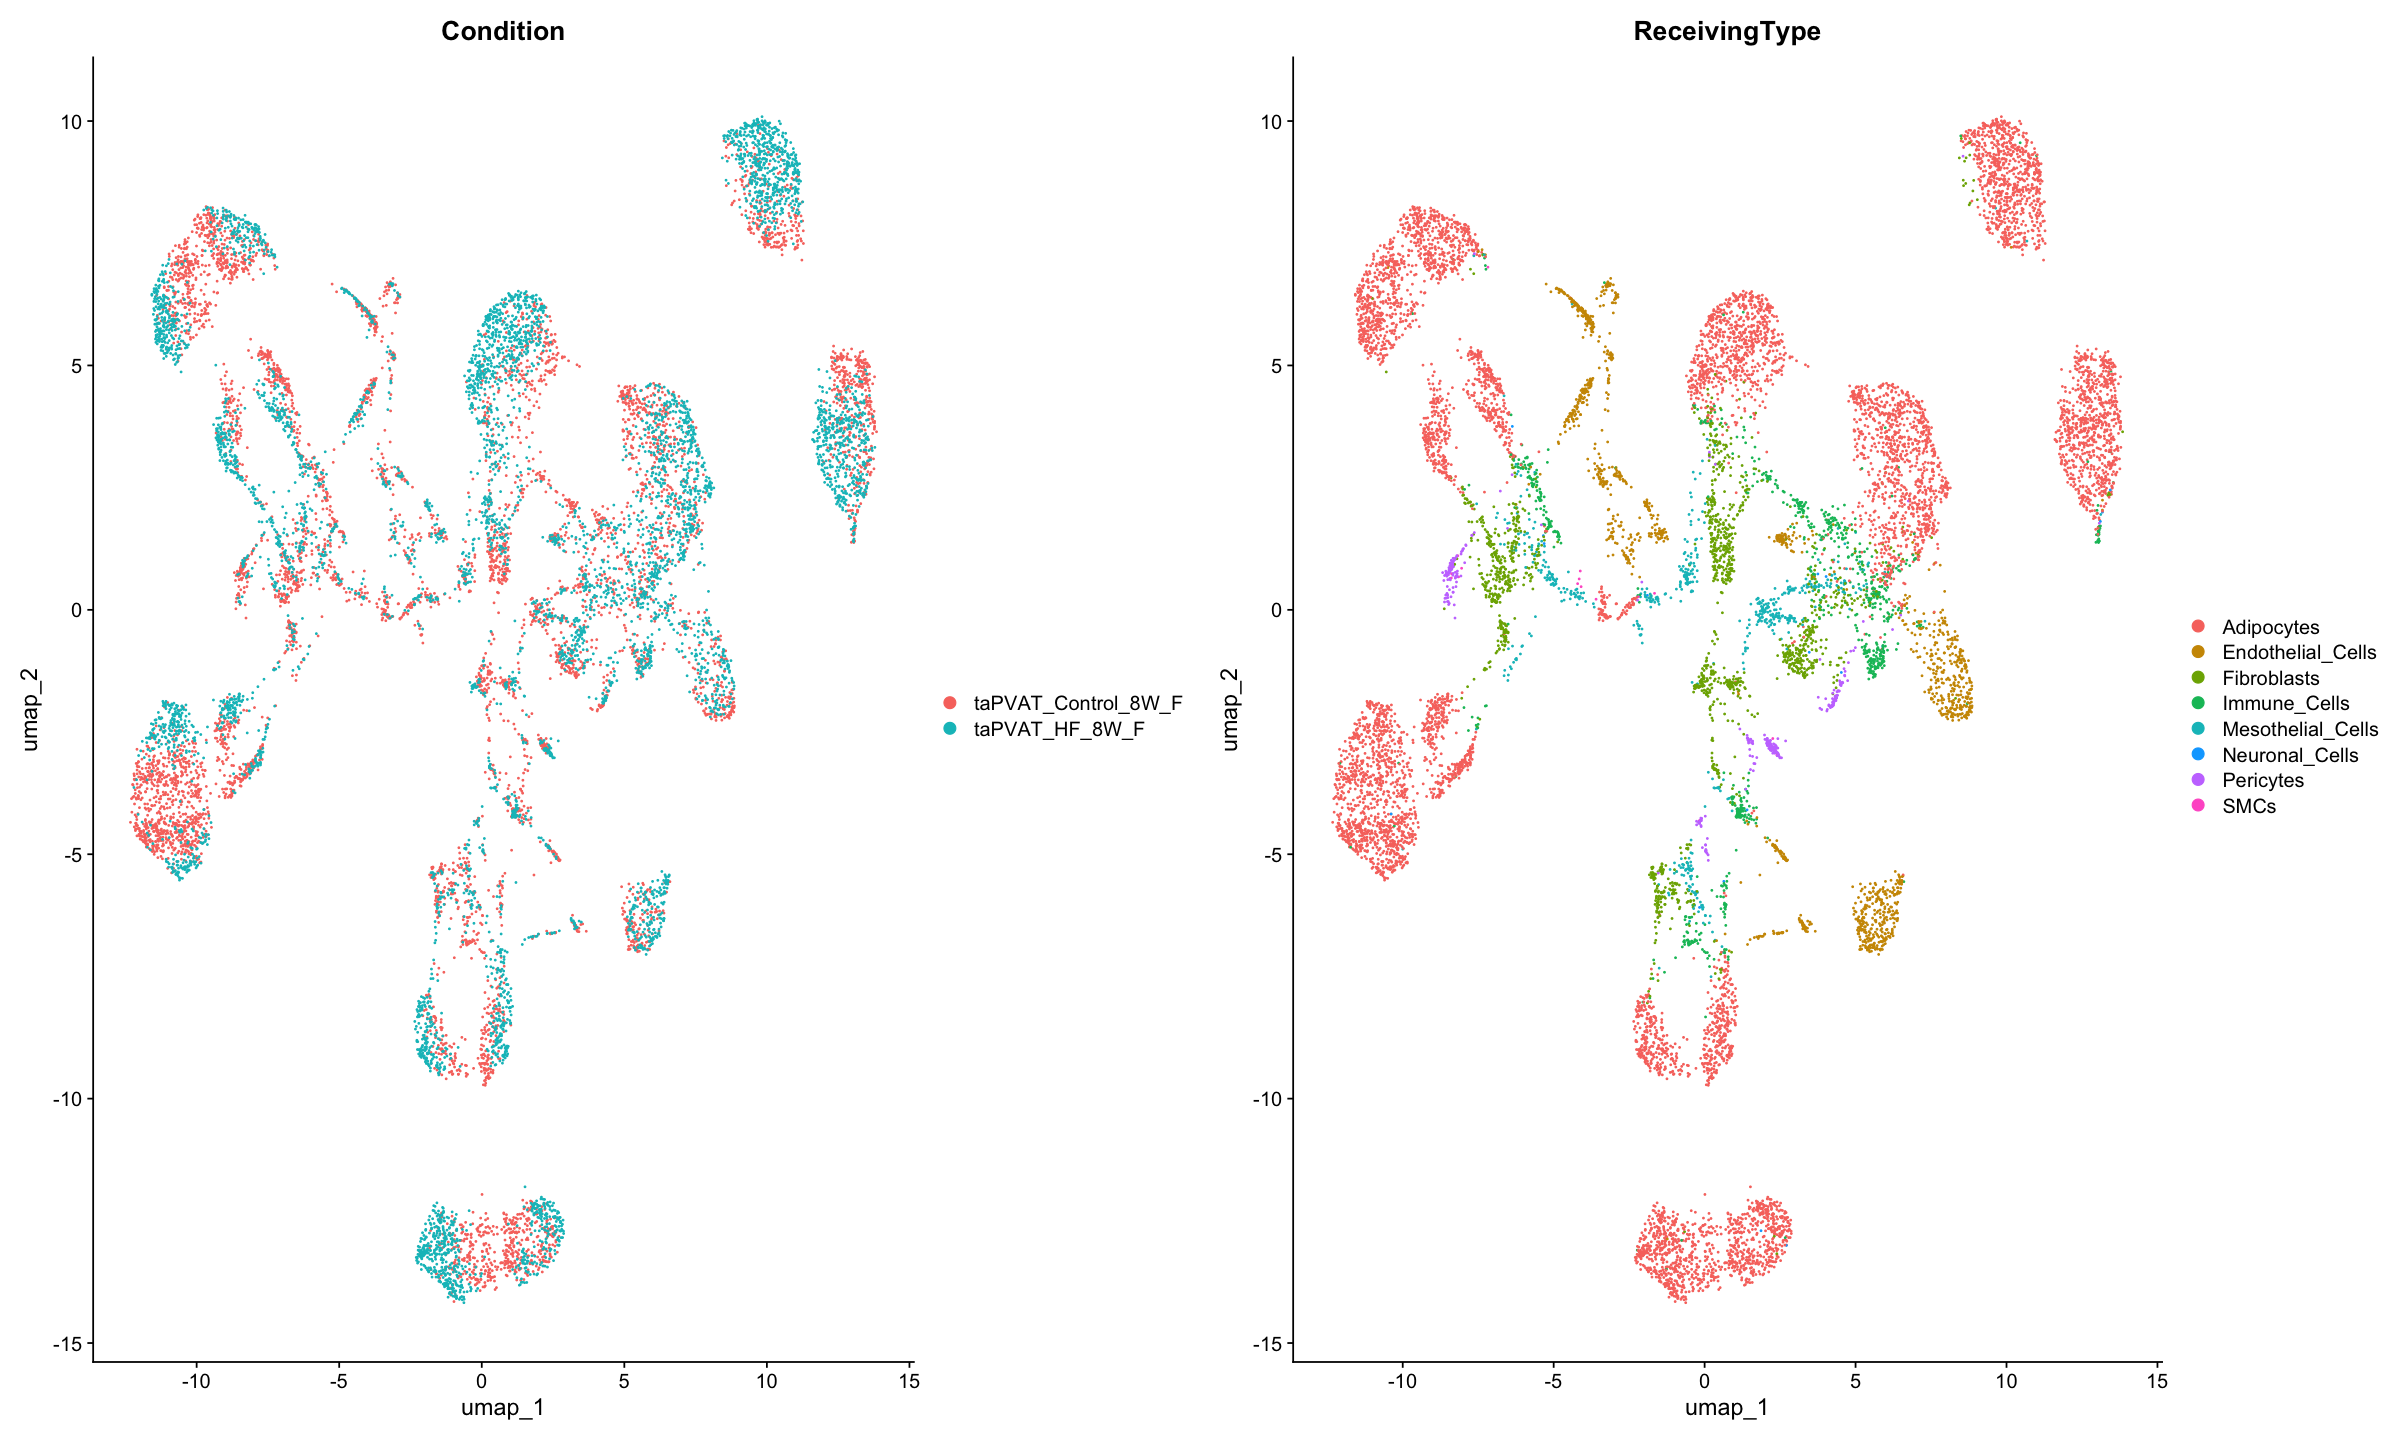

In [22]:
scc.sub <- RunUMAP(scc.sub,dims = 1:10)
p1 <- DimPlot(scc.sub,group.by = 'Condition')
p2 <- DimPlot(scc.sub,group.by = 'ReceivingType')
plot_grid(p1,p2)

In [23]:
unique(scc.sub@meta.data$ReceivingType)
COI <- "Adipocytes"

[1] "Adipocytes"        "Fibroblasts"       "Endothelial_Cells"
[4] "Immune_Cells"      "Pericytes"         "Mesothelial_Cells"
[7] "SMCs"              "Neuronal_Cells"

In [24]:
results <- lapply(COI, function(x){
 
  #subset
  subs <- subset(scc.sub, subset = ReceivingType == x)

  subs <- JoinLayers(subs, layers = c("data", "scale.data"))
  
  #print number of cells per condition
  print(paste0(x , ":  taPVAT_Control_8W_F:", sum(subs@meta.data$Condition == "taPVAT_Control_8W_F")))
  print(paste0(x , ":  taPVAT_HF_8W_F:", sum(subs@meta.data$Condition == "taPVAT_HF_8W_F")))
  
  #set idents
  Idents(subs) <- subs@meta.data$Condition
  
  #scale the subsetted data
  FindVariableFeatures(subs,assay='SystemToCell',selection.method = "disp")
  ScaleData(subs, assay='SystemToCell')
  
  #find markers (here we use ROC)
  markers <- FindAllMarkers(subs, test.use = "roc",assay='SystemToCell',
                            min.pct = 0.1,logfc.threshold = 0.1,
                            return.thresh = 0.1,only.pos = T)
  print(markers)
  
  #subset to top 10 markers per condition
  top10 <- markers %>% group_by(cluster) %>% top_n(n = 10, wt = myAUC)
  list(subs = subs, top10 = top10)
  
  #Make a heatmap
  #DoHeatmap(subs,group.by="ident",features=top10$gene, assay="SystemToCell") +  ggtitle("Top DE SystemToCell Mechanisms, CTRL vs STIM: ",x)
 
  
})

options(repr.plot.width=20, repr.plot.height=12)
options(warn=-1)

subs <- results[[1]]$subs
top10 <- results[[1]]$top10

[1] "Adipocytes:  taPVAT_Control_8W_F:3788"
[1] "Adipocytes:  taPVAT_HF_8W_F:4188"


Finding variable features for layer data

Centering and scaling data matrix

Calculating cluster taPVAT_Control_8W_F

Calculating cluster taPVAT_HF_8W_F



                 myAUC     avg_diff power avg_log2FC pct.1 pct.2
Fgf2—Nrp1        0.962 0.0602885129 0.924  8.0298959 0.924 0.000
Rspo3—Lrp6       0.926 0.0703925524 0.852  0.9943952 0.950 0.933
Cntn4—Ptprg      0.879 0.0494171853 0.758  7.7364948 0.758 0.000
Fgf2—Fgfr1       0.840 0.0255248092 0.680  6.7731980 0.680 0.000
Fgf14—Fgfr1      0.840 0.0307679964 0.680  7.0440091 0.680 0.000
Rspo1—Lrp6       0.819 0.0411981075 0.638  0.4717431 0.950 0.933
Sema3e—Nrp1      0.812 0.0572354708 0.624  0.5714714 0.924 0.896
Bmp5—Bmpr2       0.812 0.0312719771 0.624  7.0676167 0.624 0.000
Fgf7—Nrp1        0.796 0.0787672795 0.592  0.5457570 0.924 0.896
Tgfb1—Tgfbr3     0.779 0.0527477136 0.558  1.0990289 0.803 0.712
Ptn—Ptprs        0.769 0.0213085943 0.538  6.5125994 0.538 0.000
Plg—Itgb1        0.739 0.0051061295 0.478  4.4947200 0.478 0.000
Lamc3—Itgb1      0.739 0.0660371175 0.478  8.1649328 0.478 0.000
Calm1—Insr       0.737 0.1774516307 0.474  1.2158738 0.740 0.556
Serpinc1—Lrp1    0.724 0.

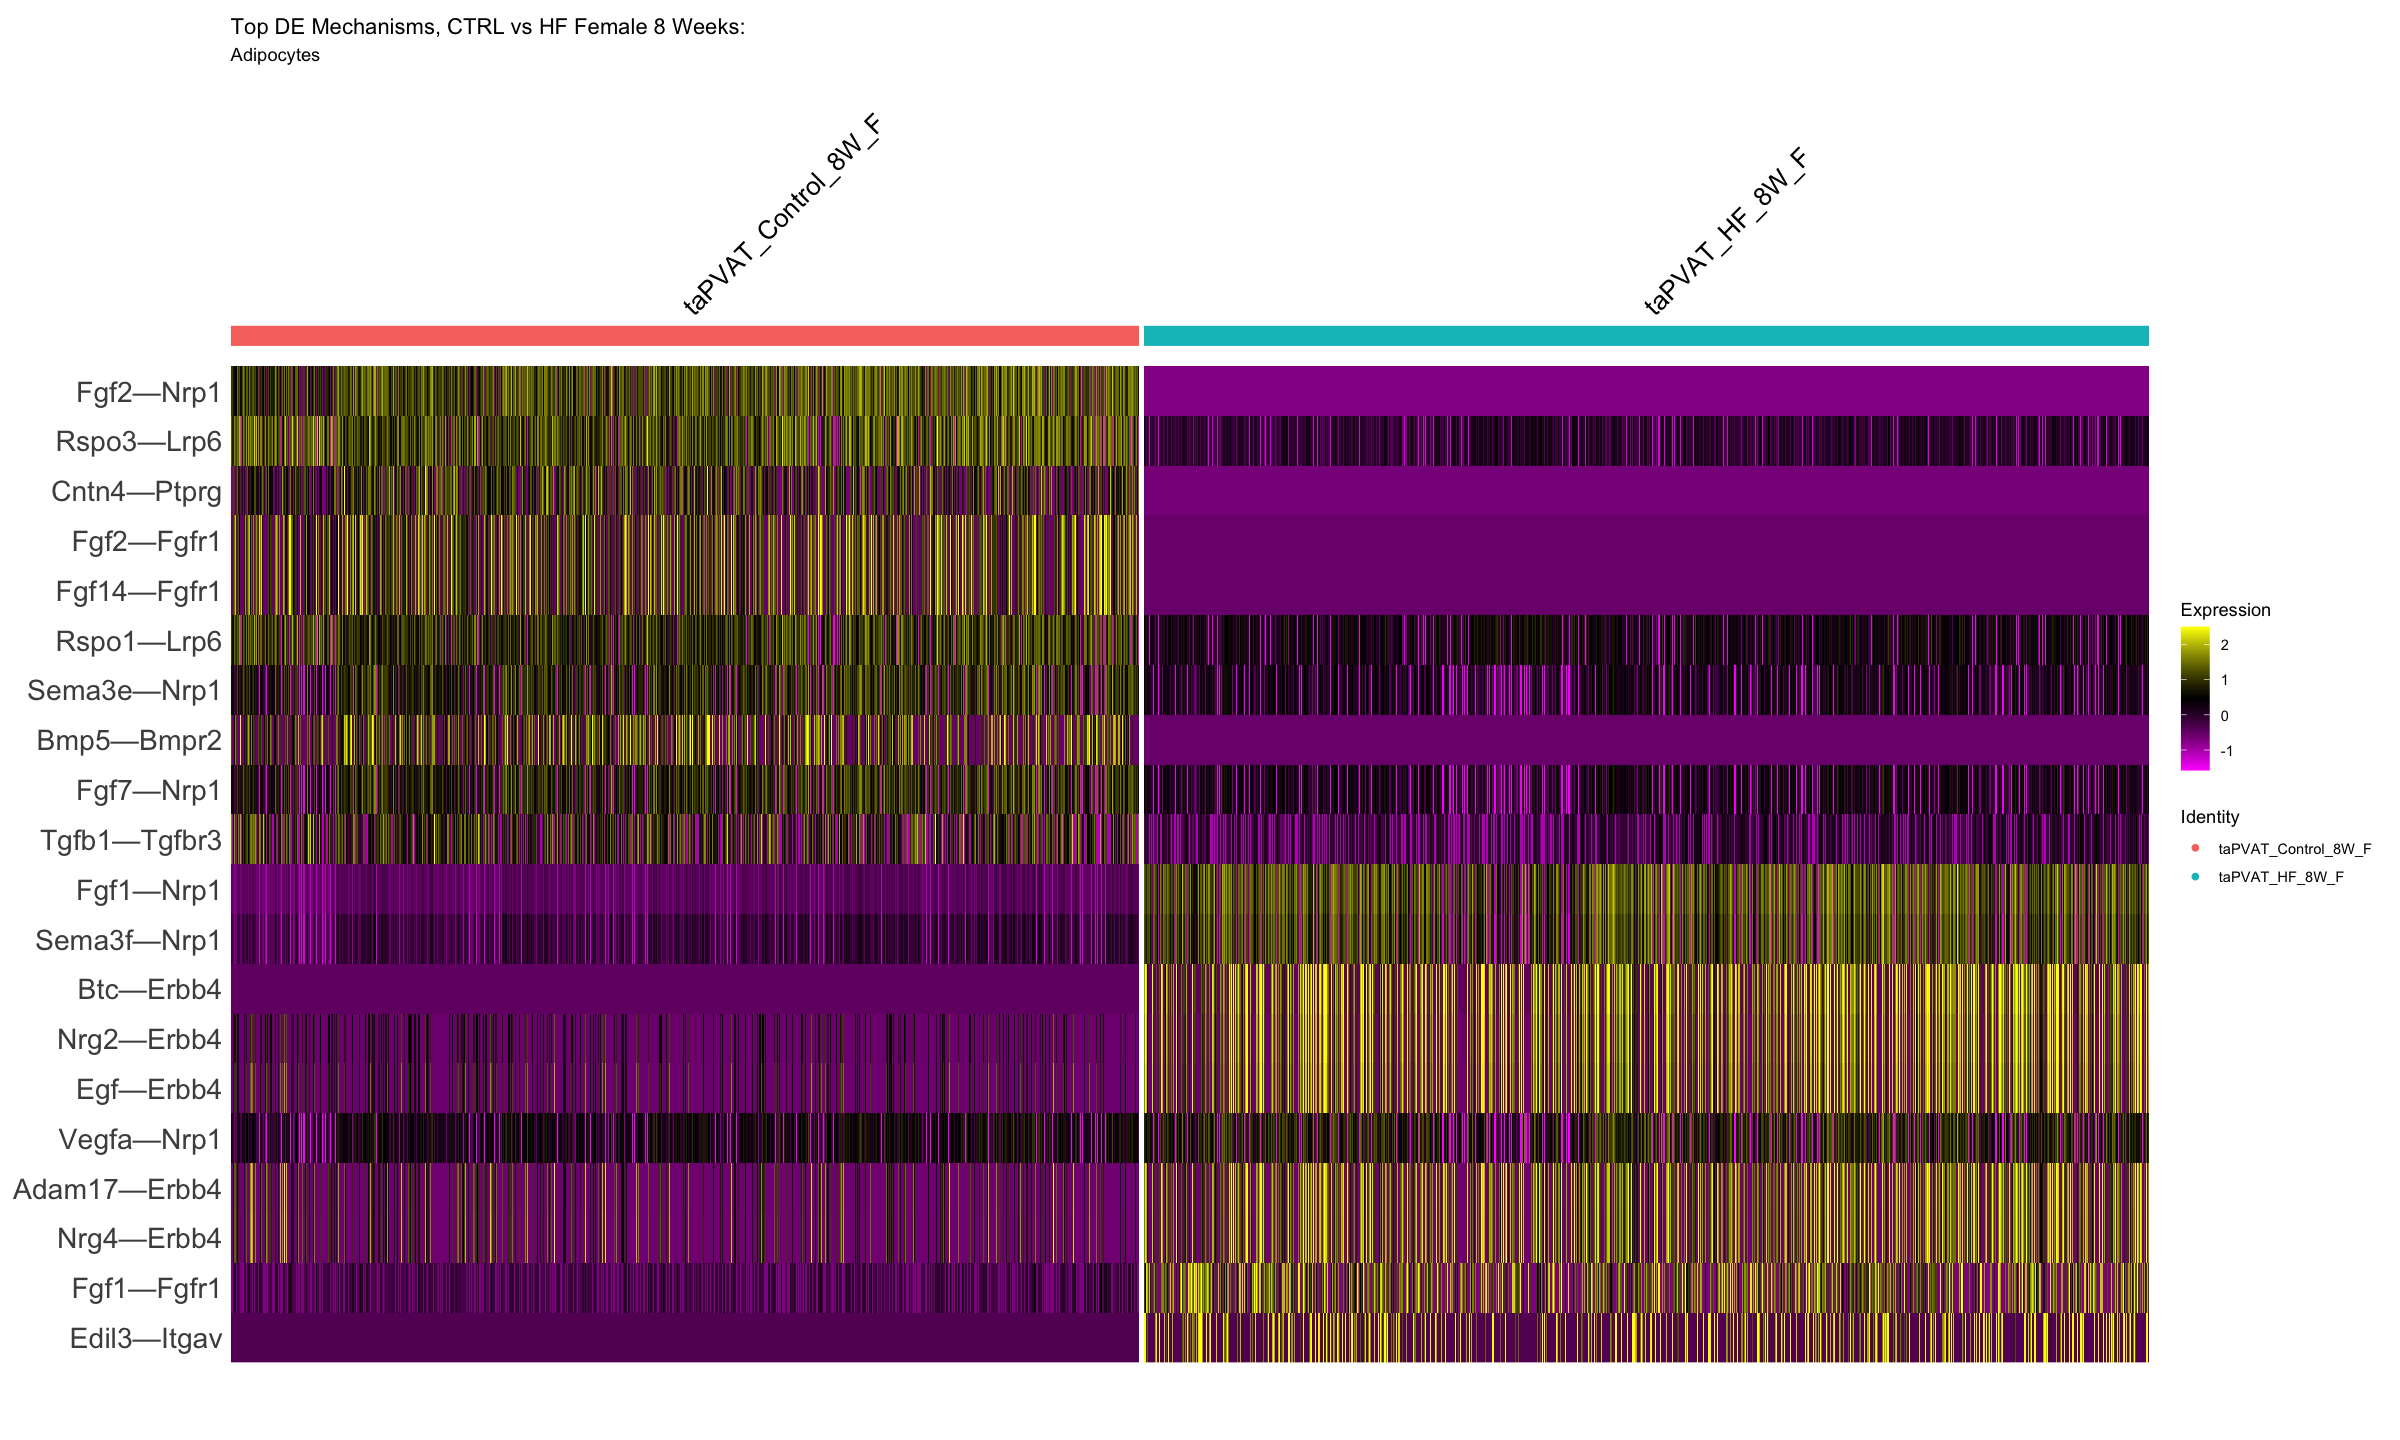

In [25]:
DoHeatmap(subs,group.by="ident",features=top10$gene, assay="SystemToCell") +  ggtitle("Top DE Mechanisms, CTRL vs HF Female 8 Weeks: ",COI) + theme(#axis.text.x = element_text(face = "italic", size = 20),
                                                                   axis.text.y = element_text(size = 17))
                                                                   #axis.title.x = element_text(size = 20),
                                                                   #axis.title.y = element_text(size = 20),
                                                                   #plot.title = element_text(hjust = 0.5))

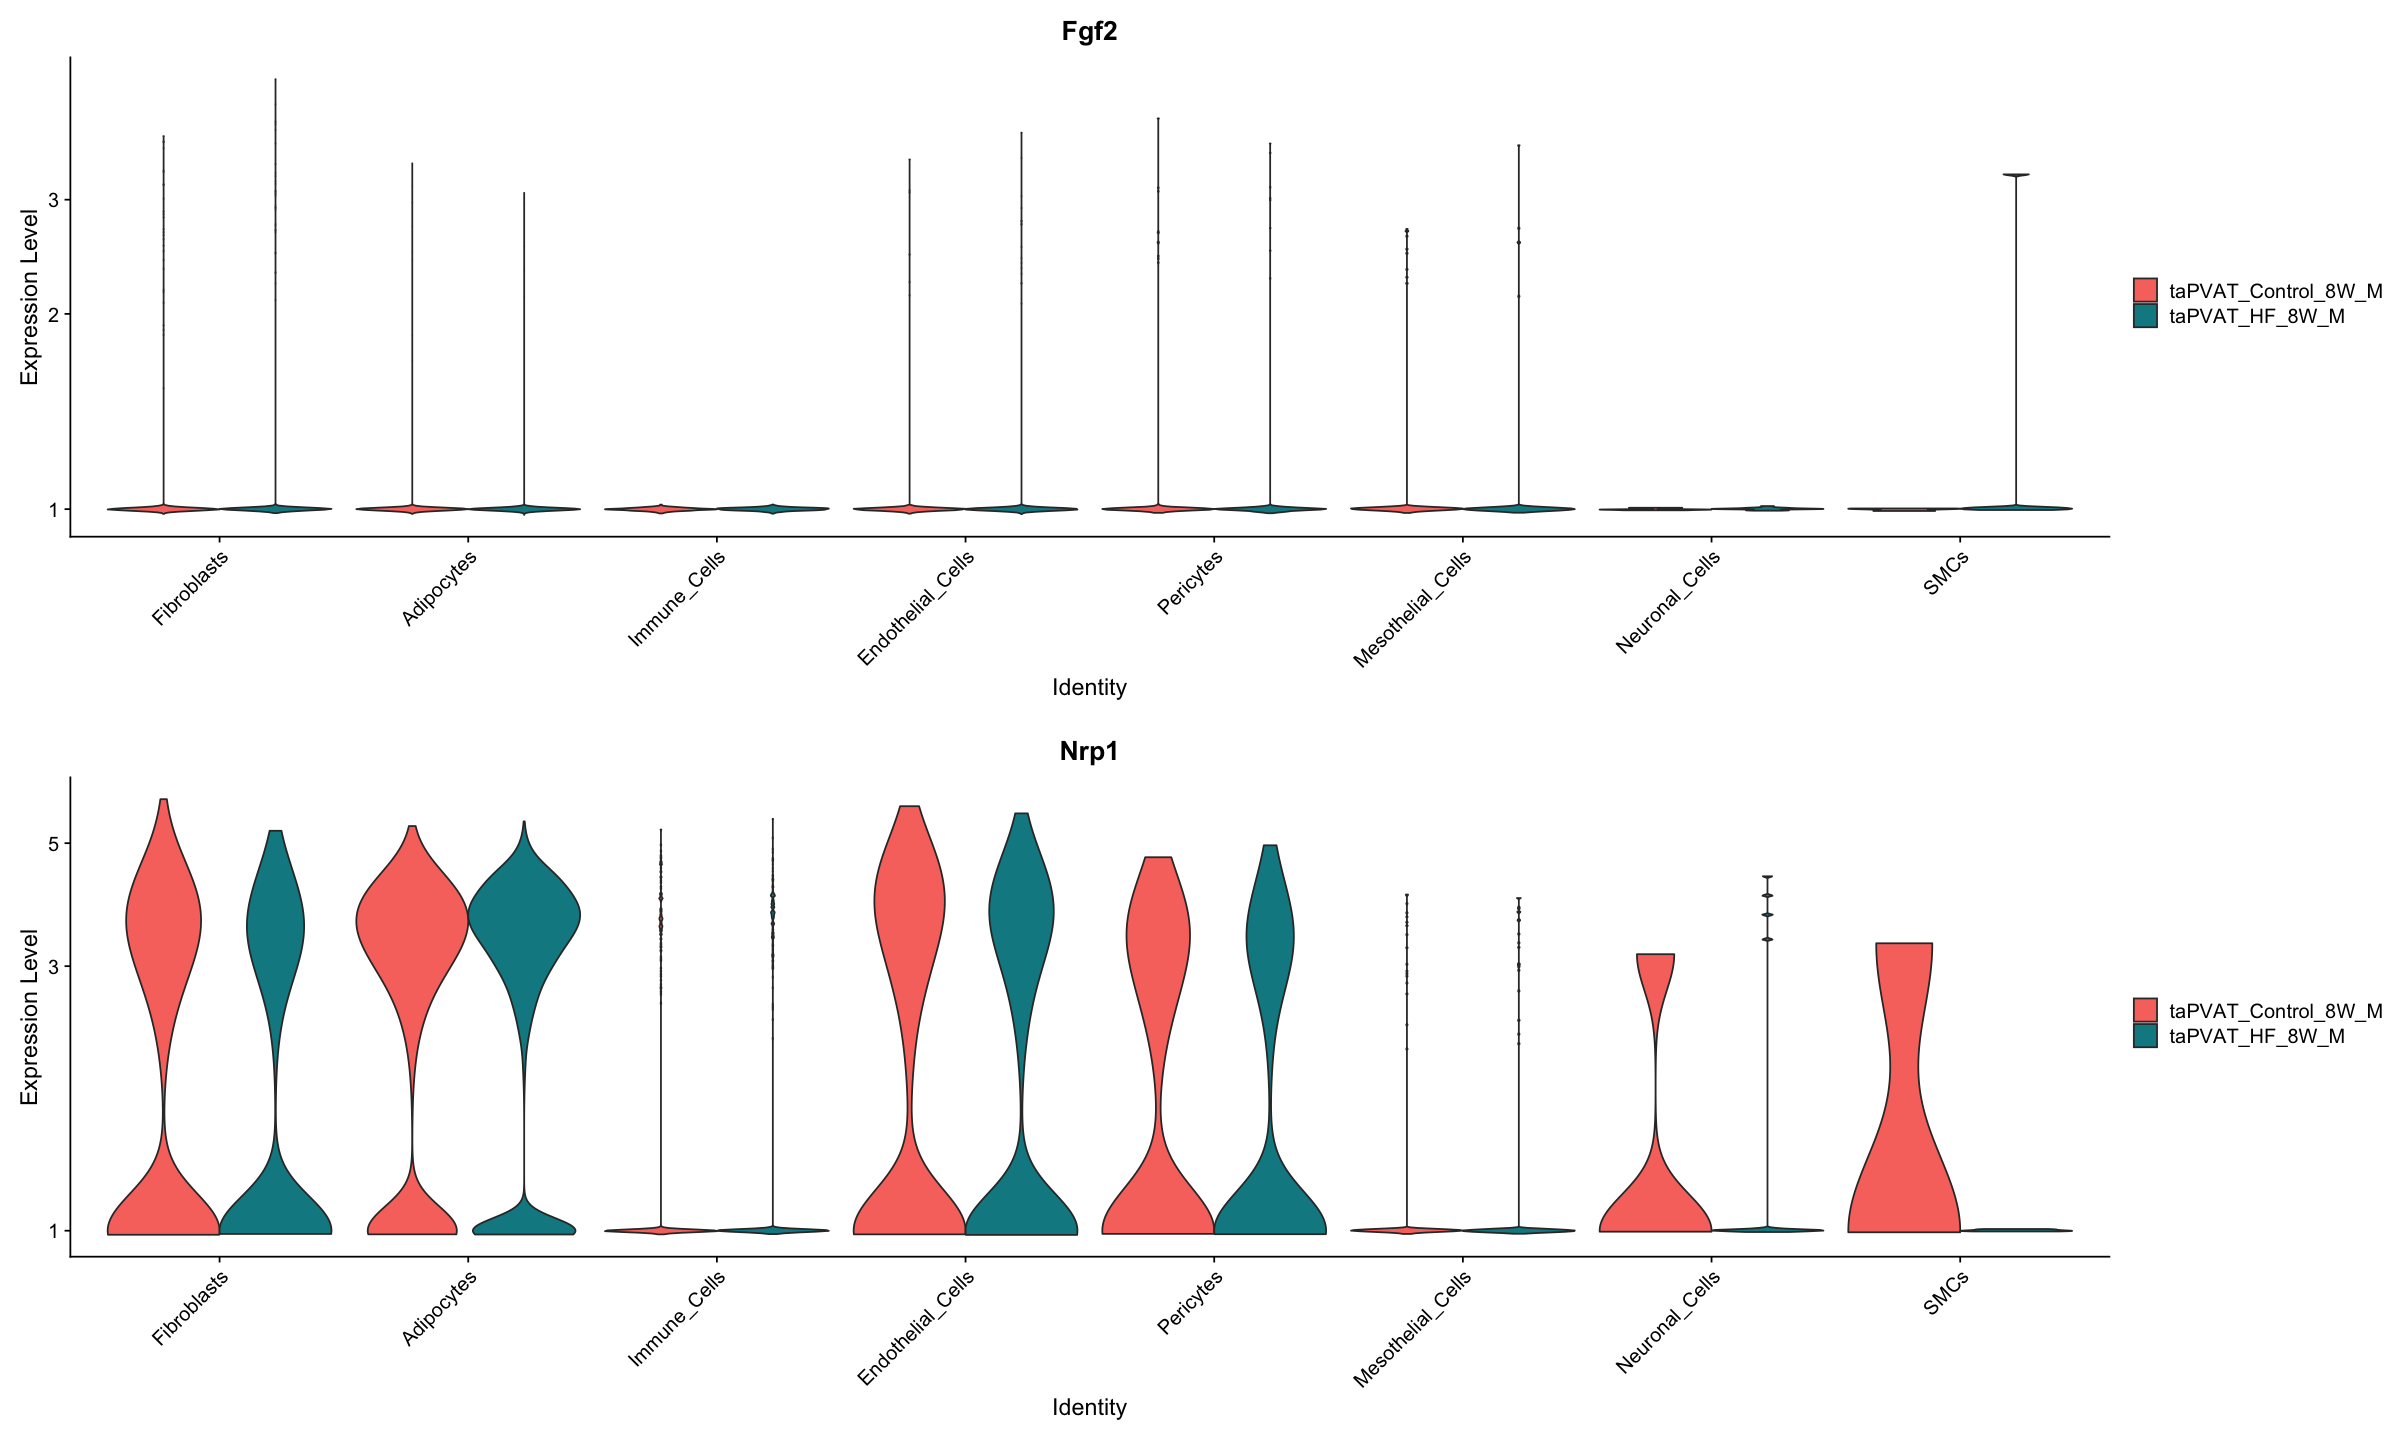

In [66]:
p1 <- VlnPlot(male_8weeks_rds,'Fgf2',split.by = 'sample_type',pt.size = 0,log=T)
p2 <- VlnPlot(male_8weeks_rds,'Nrp1',split.by = 'sample_type',pt.size = 0,log=T)
plot_grid(p1,p2,ncol=1)

Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'Rspo1—Lrp6' in 'mbcsToSbcs': dot substituted for <e2>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'Rspo1—Lrp6' in 'mbcsToSbcs': dot substituted for <80>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'Rspo1—Lrp6' in 'mbcsToSbcs': dot substituted for <94>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'Rspo1—Lrp6' in 'mbcsToSbcs': dot substituted for <e2>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'Rspo1—Lrp6' in 'mbcsToSbcs': dot substituted for <80>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'Rspo1—Lrp6' in 'mbcsToSbcs': dot substituted for <94>”
Warning message in grid.Call(C_tex

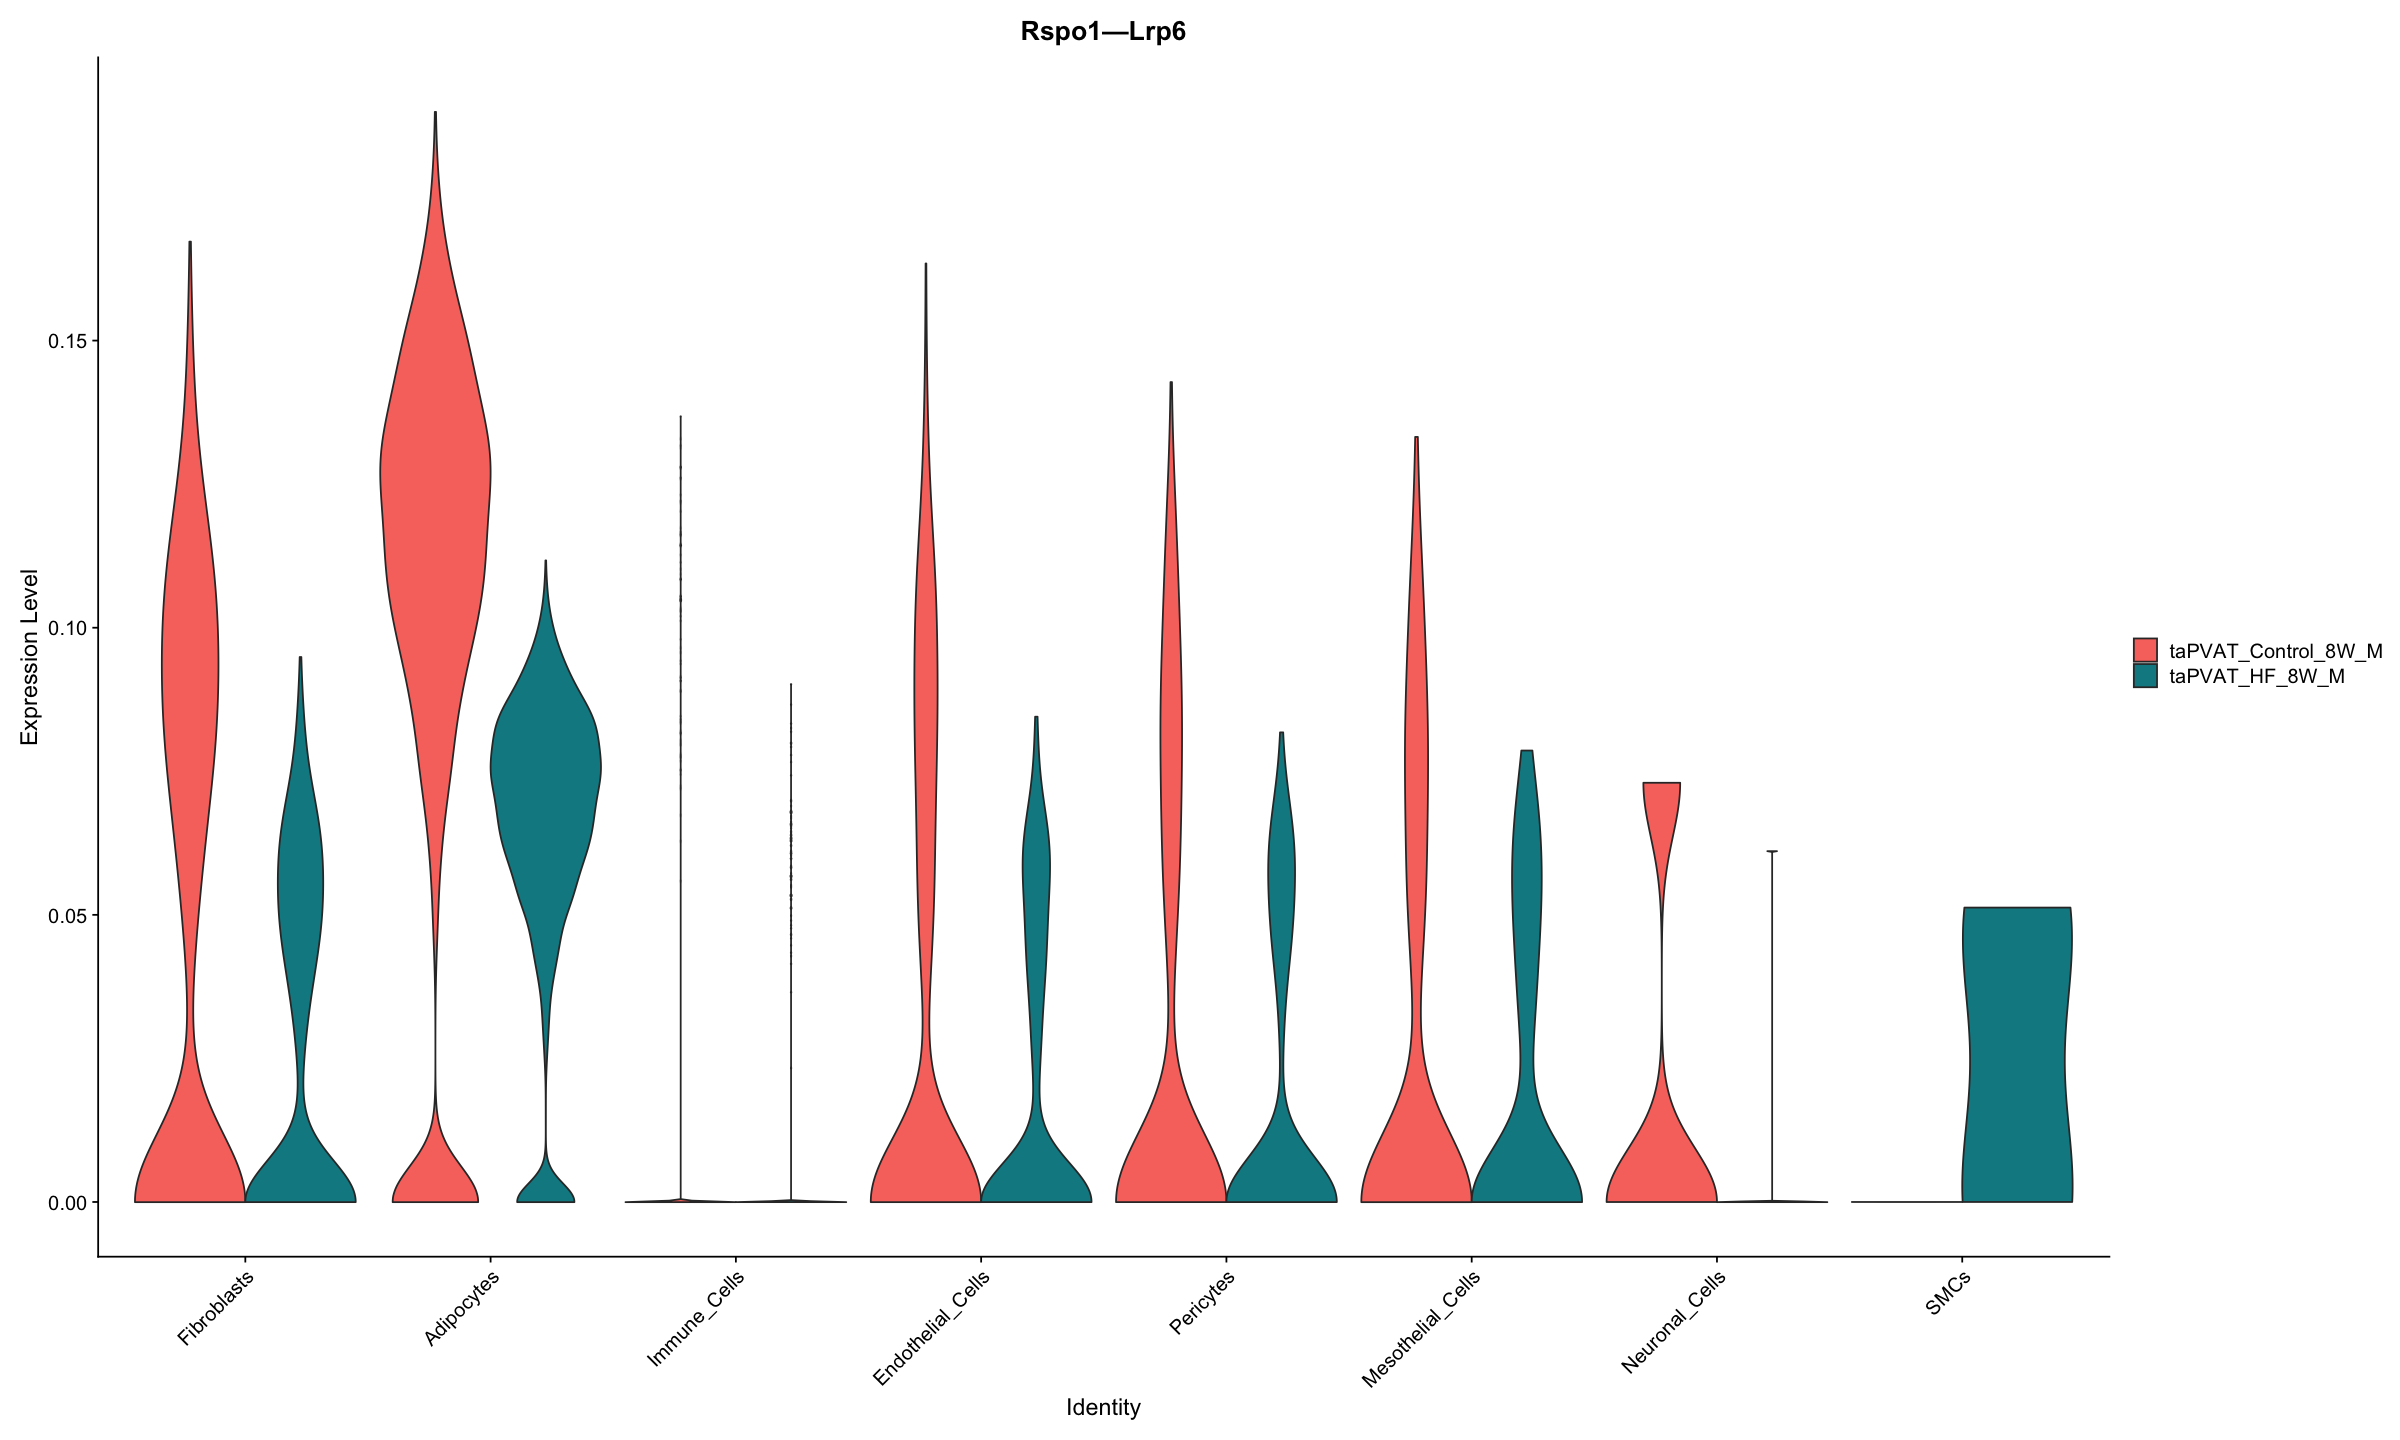

In [68]:
VlnPlot(scc.sub, 'Rspo1—Lrp6',split.by = 'Condition',pt.size = 0)

Centering and scaling data matrix

Warning message:
“Different features in new layer data than already exists for scale.data”
PC_ 1 
Positive:  Tfpi—Lrp1, Calr—Lrp1, Serpine2—Lrp1, App—Lrp1, F8—Lrp1, Psap—Lrp1, Hsp90b1—Lrp1, Lpl—Lrp1, Plat—Lrp1, Lrpap1—Lrp1 
	   Nxph1—Nrxn1, Serping1—Lrp1, Psen1—Notch1, Mfap5—Notch1, Dll1—Notch1, Uba52—Notch1, Dll4—Notch1, Adam17—Notch1, Jag1—Notch1, Jag2—Notch1 
	   Rarres2—Cmklr1, Pdgfb—Lrp1, Ptn—Ptprs, Calr—Tshr, Apoe—Lrp1, Gnas—Tshr, Fn1—Tshr, Hspg2—Ptprs, Gnai2—Tshr, Icam1—Egfr 
Negative:  Lama2—Itgb1, Col1a1—Itgb1, Lamc1—Itgb1, Nid1—Itgb1, Col6a2—Itgb1, Adam9—Itgb1, Lamb1—Itgb1, Vtn—Itgb1, Adam12—Itgb1, Fn1—Itgb1 
	   Col6a1—Itgb1, Fbn1—Itgb1, Col4a1—Itgb1, Cxcl12—Itgb1, Col5a2—Itgb1, Col6a3—Itgb1, Fbln1—Itgb1, Col18a1—Itgb1, Timp2—Itgb1, Col1a2—Itgb1 
	   Hspg2—Itgb1, Adam15—Itgb1, Lama5—Itgb1, Col3a1—Itgb1, Col4a4—Itgb1, Npnt—Itgb1, Reln—Itgb1, Tgm2—Itgb1, Vcan—Itgb1, Col4a5—Itgb1 
PC_ 2 
Positive:  Vegfc—Itgb1, Col4a5—Itgb1, Vcam1—Itgb1, Reln—

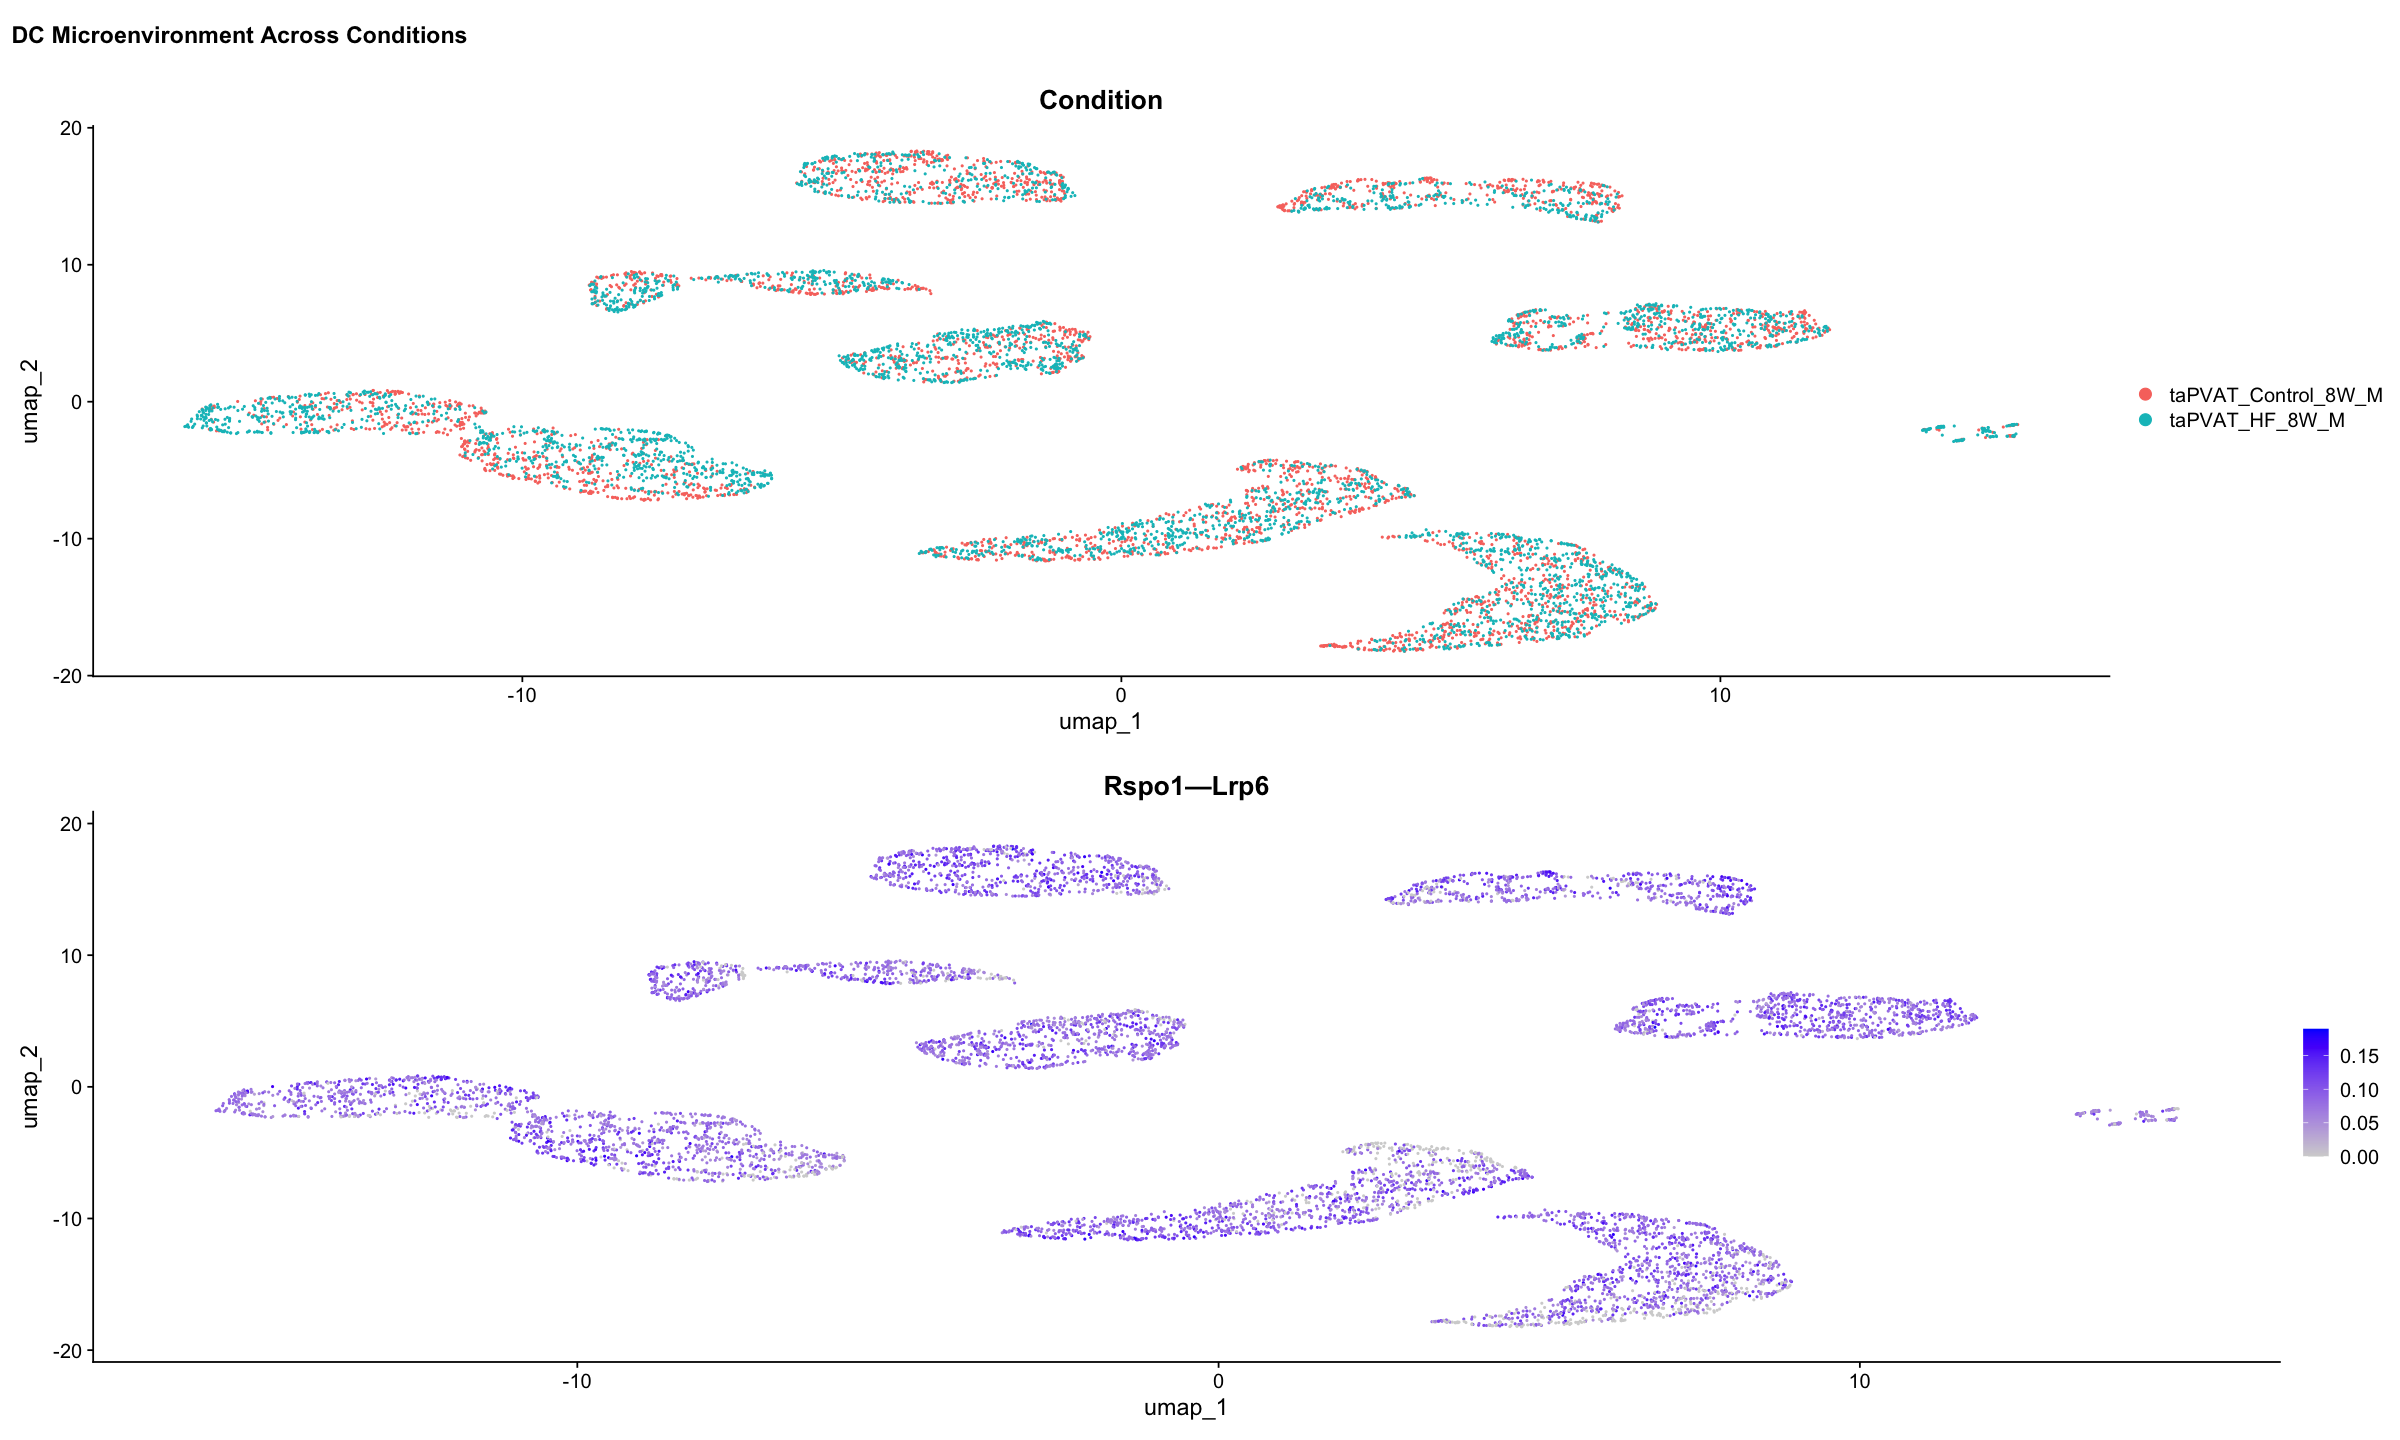

In [69]:
subs <- subset(scc.sub, idents = 'Adipocytes')
subs <- ScaleData(subs)
subs <- RunPCA(subs)
subs <- RunUMAP(subs,dims = 1:5)
p1 <- DimPlot(subs,group.by = 'Condition')
p2 <- FeaturePlot(subs,'Rspo1—Lrp6')
title <- ggdraw() + 
  draw_label(
    "DC Microenvironment Across Conditions",
    fontface = 'bold',
    x = 0,
    hjust = 0
  ) +
  theme(
    # add margin on the left of the drawing canvas,
    # so title is aligned with left edge of first plot
    plot.margin = margin(0, 0, 0, 7)
  )
plot_grid(title,p1,p2,ncol=1,rel_heights = c(0.1, 1,1))